<a href="https://colab.research.google.com/github/EJamesssss/EJamesssss/blob/main/Advanced_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Description

This project presenst a Topic Classification Review of Sephora Product Reviews. Using Sephora Product review data, this project demonstrates how customer review data can be transformed into actionable insights for product improvement, marketing strategy, customer experience, and personalized beauty recommendation.

## Table of Contents

In [243]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline

In [244]:
file_path = r'/content/drive/MyDrive/Python Bootcamp Uplift/Sephora Reviews.csv'

In [245]:
df = pd.read_csv(file_path)

/tmp/ipykernel_3078/2618208116.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


In [246]:
df.head(3)

,Unnamed: 0,author_id,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,review_title,skin_tone,eye_color,skin_type,hair_color,product_id,product_name,brand_name,price_usd
0,0,1945004256,5,1.0,0.000000,2,2,0,2022-12-10,I absolutely L-O-V-E this oil. I have acne pro...,A must have!,lightMedium,green,combination,NaN,P379064,Lotus Balancing & Hydrating Natural Face Treat...,Clarins,65.0
1,1,5478482359,3,1.0,0.333333,3,2,1,2021-12-17,I gave this 3 stars because it give me tiny li...,it keeps oily skin under control,mediumTan,brown,oily,black,P379064,Lotus Balancing & Hydrating Natural Face Treat...,Clarins,65.0
2,2,29002209922,5,1.0,1.000000,2,0,2,2021-06-07,Works well as soon as I wash my face and pat d...,Worth the money!,lightMedium,brown,dry,black,P379064,Lotus Balancing & Hydrating Natural Face Treat...,Clarins,65.0


In [247]:
df.isnull().sum()


,0
Unnamed: 0,0
author_id,0
rating,0
is_recommended,3817
helpfulness,13455
total_feedback_count,0
total_neg_feedback_count,0
total_pos_feedback_count,0
submission_time,0
review_text,59


In [248]:
df['review_text'].isnull().sum()
df = df.dropna()

In [249]:
df.isnull().sum()

,0
Unnamed: 0,0
author_id,0
rating,0
is_recommended,0
helpfulness,0
total_feedback_count,0
total_neg_feedback_count,0
total_pos_feedback_count,0
submission_time,0
review_text,0


# Exploratory Data Analysis

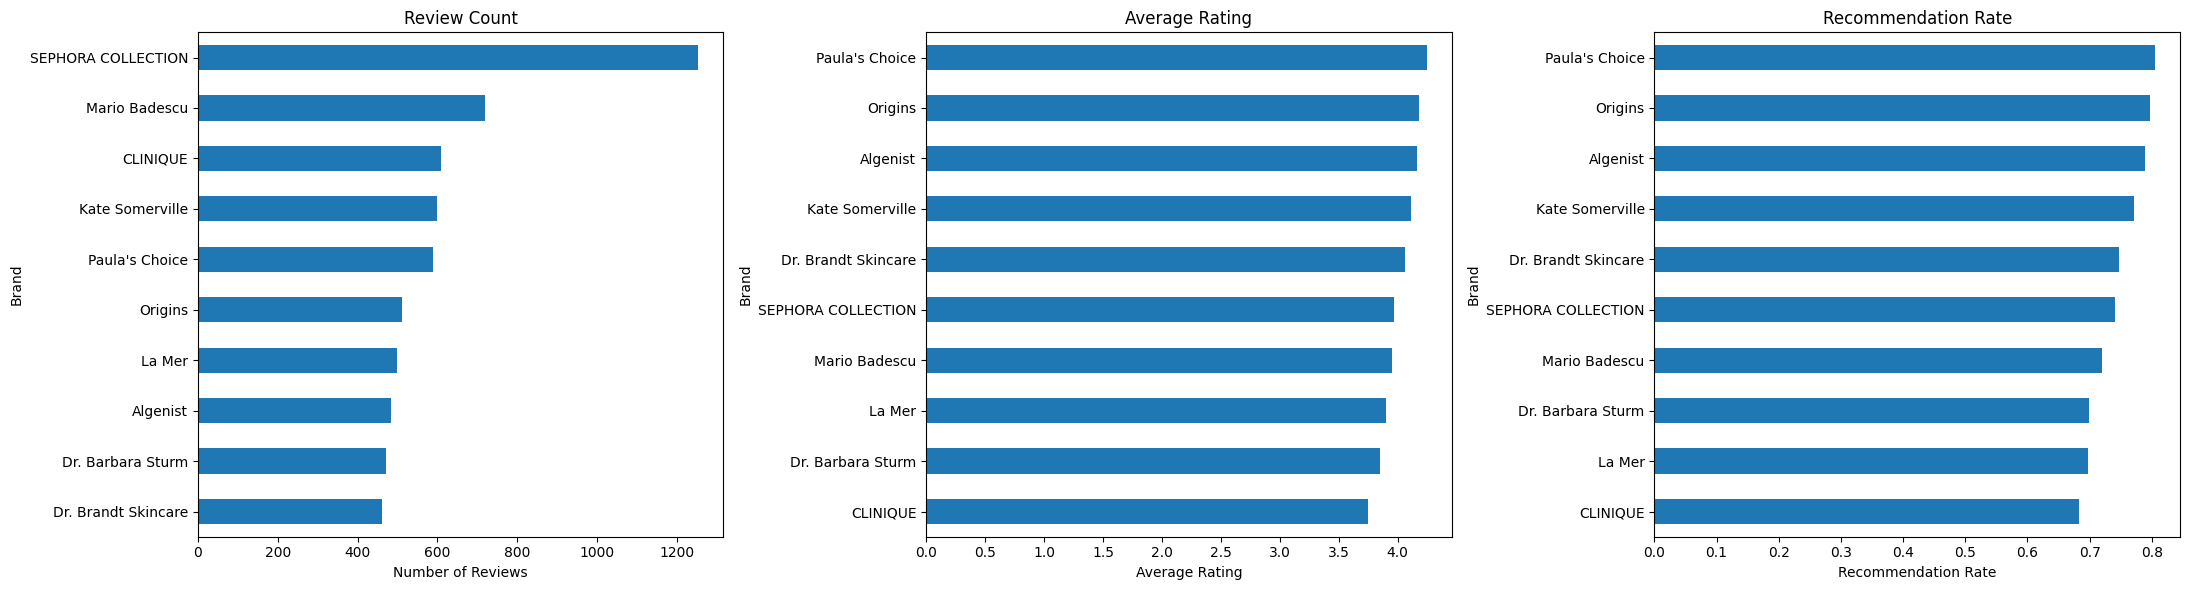

In [300]:
brand_summary = df.groupby('brand_name').agg(
    review_count=('review_text', 'count'),
    avg_rating=('rating', 'mean'),
    recommendation_rate=('is_recommended', 'mean'),
    avg_price=('price_usd', 'mean')
).sort_values('review_count', ascending=False)

top_brands = brand_summary.head(10)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

top_brands['review_count'].sort_values().plot(
    kind='barh',
    ax=axes[0],
    title='Review Count'
)

top_brands['avg_rating'].sort_values().plot(
    kind='barh',
    ax=axes[1],
    title='Average Rating'
)

top_brands['recommendation_rate'].sort_values().plot(
    kind='barh',
    ax=axes[2],
    title='Recommendation Rate'
)

axes[0].set_xlabel('Number of Reviews')
axes[1].set_xlabel('Average Rating')
axes[2].set_xlabel('Recommendation Rate')

for ax in axes:
    ax.set_ylabel('Brand')

plt.tight_layout()
plt.show()

Top reviewed brands indicate which brands generate the most customer engagement. However, review volumne alone does not confirm customer satisfaction. By comparing review count with average rating and recommendation rate, we can identify brands that are both popular and well-received, as well as brands with high visibility but possible customer satisfaction issues.

In [301]:
df['price_band'] = pd.cut(
    df['price_usd'],
    bins=[0, 25, 50, 100, 500],
    labels=['Budget', 'Mid-range', 'Premium', 'Luxury']
)

price_summary = df.groupby('price_band').agg(
    review_count=('review_text', 'count'),
    avg_rating=('rating', 'mean'),
    recommendation_rate=('is_recommended', 'mean')
)


/tmp/ipykernel_3078/245699630.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_summary = df.groupby('price_band').agg(


,review_count,avg_rating,recommendation_rate
price_band,,,
Budget,5150,3.969126,0.738835
Mid-range,7140,4.073950,0.767087
Premium,5862,4.197714,0.793415
Luxury,2988,4.073293,0.763052


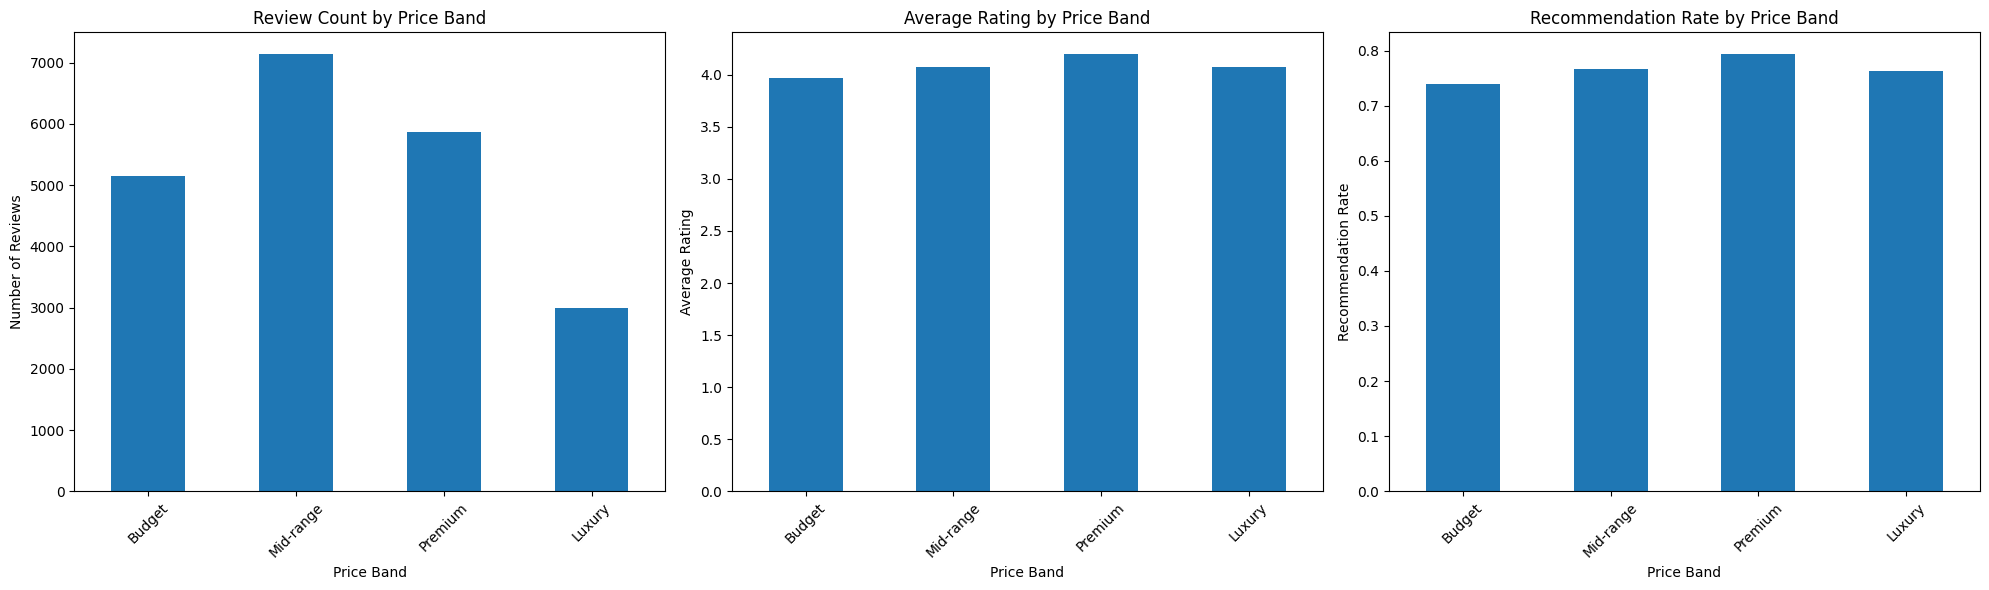

In [302]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

price_summary['review_count'].plot(
    kind='bar',
    ax=axes[0],
    title='Review Count by Price Band'
)

price_summary['avg_rating'].plot(
    kind='bar',
    ax=axes[1],
    title='Average Rating by Price Band'
)

price_summary['recommendation_rate'].plot(
    kind='bar',
    ax=axes[2],
    title='Recommendation Rate by Price Band'
)

axes[0].set_ylabel('Number of Reviews')
axes[1].set_ylabel('Average Rating')
axes[2].set_ylabel('Recommendation Rate')

for ax in axes:
    ax.set_xlabel('Price Band')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

The graph suggests that higher price does not always mean ihgher customer engagement. Mid-range products receive the most reviews, indicating stronger customer reach and purchase activity. However, premium products show the highest average rating and recommendation rate, suggesting that customers may perceive premium items as offering the best balance between quality and value

# Text Analysis

In [250]:
sentiment_model = "cardiffnlp/twitter-roberta-base-sentiment-latest"
classifier = pipeline("sentiment-analysis", model=sentiment_model, tokenizer=sentiment_model)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [251]:
df['review_text'] = df['review_text'].fillna("").astype(str)

In [252]:
df_smaller = df.sample(n=300, random_state=150)

In [253]:
df_smaller

,Unnamed: 0,author_id,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,review_title,skin_tone,eye_color,skin_type,hair_color,product_id,product_name,brand_name,price_usd
33166,33166,1361126724,4,1.0,0.911765,68,6,62,2018-03-11,"I love this. The price point is awesome, consi...",Make the investment- your skin will thank you,mediumTan,green,normal,brown,P398500,Personal Microderm,PMD,159.0
32228,32228,1480201626,1,0.0,1.000000,10,0,10,2019-07-04,Do not use if you have oily or combo skin. The...,Not for oily or combo skin,deep,brown,combination,black,P440501,Seaweed Night Cream,Mario Badescu,22.0
24280,24280,2218140752,5,1.0,1.000000,3,0,3,2019-07-05,"As amazing, easy and effective as this product...",Best STRONG exfoliator,fair,brown,dry,auburn,P431733,Epidermal Re-Texturizing Micro-Dermabrasion,Kiehl's Since 1851,46.0
36852,36852,24095308723,5,1.0,1.000000,1,0,1,2021-09-30,This cleanser is so great! It removes perfectl...,Good!,light,blue,combination,brown,P472343,Superkind Fragrance-Free Softening Cleanser,Tata Harper,88.0
3489,3489,27866383622,5,1.0,1.000000,3,0,3,2020-12-03,I am so happy and blown away. I have a tooth t...,Amazing!,lightMedium,green,combination,brown,P395389,GLO Brilliant Teeth Whitening GLO Vials 10 Pac...,GLO Science,65.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43486,43486,2783939800,5,1.0,1.000000,2,0,2,2021-10-02,"I don’t know why but in the last 3 years, at s...",Never go without,light,brown,normal,black,P408542,One Essential Eye Serum,Dior,72.0
46454,46454,8600522543,4,1.0,1.000000,4,0,4,2021-10-10,"I have combo/oily, somewhat sensitive and acne...",Gentle yet effective,deep,brown,combination,black,P470248,Retexturizing Retinol Booster Serum,ROSE Ingleton MD,70.0
23750,23750,11665162471,5,1.0,0.884615,52,6,46,2020-04-30,I really LOVE this product ! I have post acne ...,brighter complexion,lightMedium,brown,combination,black,P453822,Dark Spots No More Triple Acid Spot Minimizing...,Dr. Brandt Skincare,71.0
44885,44885,12367901948,5,1.0,1.000000,3,0,3,2022-10-04,This feels like their now-discontinued Benefia...,This is basically their discontinued Benefiance,mediumTan,brown,oily,black,P423164,Future Solution LX Extra Rich Cleansing Foam,Shiseido,65.0


In [254]:
results = classifier(df_smaller['review_text'].tolist())

In [255]:
df_smaller['sentiment_label'] = [result['label'] for result in results]
df_smaller['sentiment_score'] = [result['score'] for result in results]

In [256]:
df_smaller

,Unnamed: 0,author_id,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,review_title,skin_tone,eye_color,skin_type,hair_color,product_id,product_name,brand_name,price_usd,sentiment_label,sentiment_score
33166,33166,1361126724,4,1.0,0.911765,68,6,62,2018-03-11,"I love this. The price point is awesome, consi...",Make the investment- your skin will thank you,mediumTan,green,normal,brown,P398500,Personal Microderm,PMD,159.0,positive,0.963432
32228,32228,1480201626,1,0.0,1.000000,10,0,10,2019-07-04,Do not use if you have oily or combo skin. The...,Not for oily or combo skin,deep,brown,combination,black,P440501,Seaweed Night Cream,Mario Badescu,22.0,negative,0.798716
24280,24280,2218140752,5,1.0,1.000000,3,0,3,2019-07-05,"As amazing, easy and effective as this product...",Best STRONG exfoliator,fair,brown,dry,auburn,P431733,Epidermal Re-Texturizing Micro-Dermabrasion,Kiehl's Since 1851,46.0,positive,0.427837
36852,36852,24095308723,5,1.0,1.000000,1,0,1,2021-09-30,This cleanser is so great! It removes perfectl...,Good!,light,blue,combination,brown,P472343,Superkind Fragrance-Free Softening Cleanser,Tata Harper,88.0,positive,0.960982
3489,3489,27866383622,5,1.0,1.000000,3,0,3,2020-12-03,I am so happy and blown away. I have a tooth t...,Amazing!,lightMedium,green,combination,brown,P395389,GLO Brilliant Teeth Whitening GLO Vials 10 Pac...,GLO Science,65.0,positive,0.979708
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43486,43486,2783939800,5,1.0,1.000000,2,0,2,2021-10-02,"I don’t know why but in the last 3 years, at s...",Never go without,light,brown,normal,black,P408542,One Essential Eye Serum,Dior,72.0,negative,0.458780
46454,46454,8600522543,4,1.0,1.000000,4,0,4,2021-10-10,"I have combo/oily, somewhat sensitive and acne...",Gentle yet effective,deep,brown,combination,black,P470248,Retexturizing Retinol Booster Serum,ROSE Ingleton MD,70.0,positive,0.700741
23750,23750,11665162471,5,1.0,0.884615,52,6,46,2020-04-30,I really LOVE this product ! I have post acne ...,brighter complexion,lightMedium,brown,combination,black,P453822,Dark Spots No More Triple Acid Spot Minimizing...,Dr. Brandt Skincare,71.0,positive,0.944382
44885,44885,12367901948,5,1.0,1.000000,3,0,3,2022-10-04,This feels like their now-discontinued Benefia...,This is basically their discontinued Benefiance,mediumTan,brown,oily,black,P423164,Future Solution LX Extra Rich Cleansing Foam,Shiseido,65.0,negative,0.722407


# Preprocessing

In [257]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [258]:
num_cols = df_smaller.select_dtypes(['int','float']).columns
cat_cols = df_smaller.select_dtypes(['object']).columns


In [259]:
transformation_pipeline = ColumnTransformer([
    ("num", SimpleImputer(strategy = 'median'), num_cols),
    ("scaler", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(), cat_cols)
])

In [260]:
for col in cat_cols:
    df_smaller[col] = df_smaller[col].astype(str)

df_smaller_trans = transformation_pipeline.fit_transform(df_smaller)

# Elbow method

In [261]:
from sklearn.cluster import KMeans

In [262]:
inertias = []
number_clusters = range(1,10)

for number_cluster in number_clusters:
  kmeans_model = KMeans(n_clusters = number_cluster, random_state = 42, n_init = 10)
  kmeans_model.fit(df_smaller_trans)
  inertias.append(kmeans_model.inertia_)

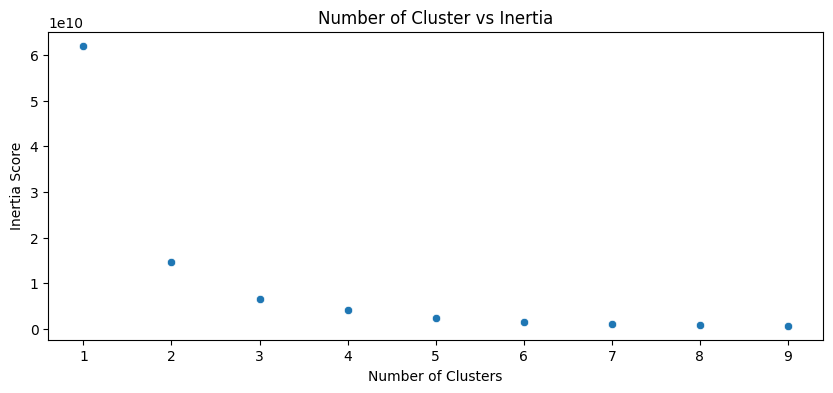

In [263]:
plt.figure(figsize=(10, 4))
sns.scatterplot(x = number_clusters, y= inertias)
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia Score')
plt.title('Number of Cluster vs Inertia')
plt.show()

# Dimensionality Reduction

In [264]:
from sklearn.decomposition import PCA

In [265]:
pca_model = PCA(n_components=3)
df_pca = pca_model.fit_transform(df_smaller_trans)

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:105: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scout = method(scout_x, scout_y, **kws)
/usr/local/lib/python3.12/dist-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)


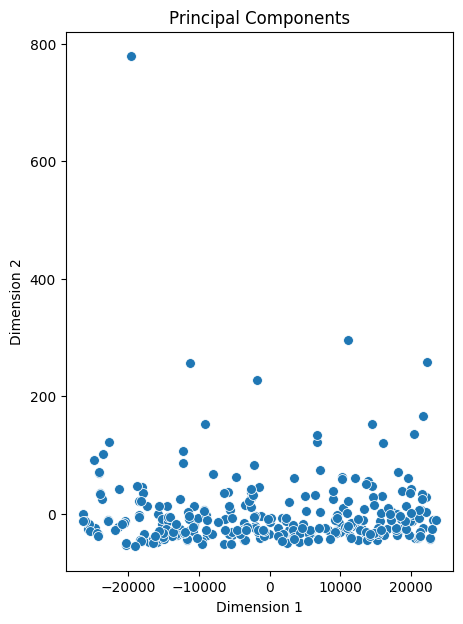

In [266]:
plt.figure(figsize=(5, 7))
sns.scatterplot(x = df_pca[:,0], y = df_pca[:,1], cmap = 'viridis', s=50)
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.title('Principal Components')
plt.show()

#KMeans Clustering

In [267]:
from sklearn.cluster import KMeans

In [268]:
kmeans_model = KMeans(n_clusters= 3, random_state=432, n_init=10)
clusters = kmeans_model.fit_predict(df_pca)

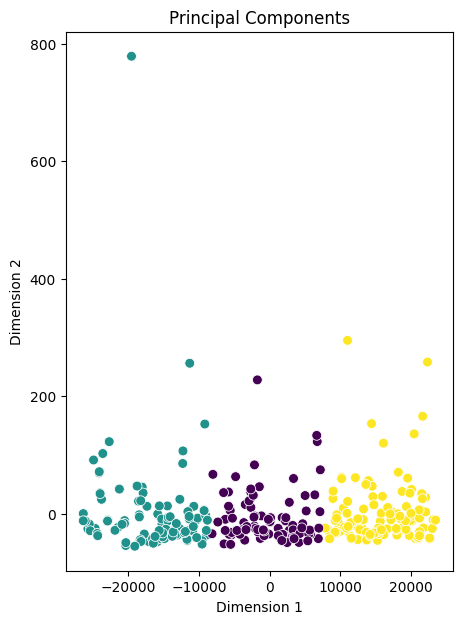

In [269]:
plt.figure(figsize=(5, 7))
sns.scatterplot(x = df_pca[:,0], y = df_pca[:,1], cmap = 'viridis', s=50, c=clusters)
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.title('Principal Components')
plt.show()

In [270]:
df_smaller['clusters'] = clusters

In [273]:
filtered_df = df_smaller[df_smaller['clusters'].isin([0,1, 2, 3])]

In [274]:
filtered_df

,Unnamed: 0,author_id,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,review_title,skin_tone,eye_color,skin_type,hair_color,product_id,product_name,brand_name,price_usd,sentiment_label,sentiment_score,clusters
33166,33166,1361126724,4,1.0,0.911765,68,6,62,2018-03-11,"I love this. The price point is awesome, consi...",Make the investment- your skin will thank you,mediumTan,green,normal,brown,P398500,Personal Microderm,PMD,159.0,positive,0.963432,0
32228,32228,1480201626,1,0.0,1.000000,10,0,10,2019-07-04,Do not use if you have oily or combo skin. The...,Not for oily or combo skin,deep,brown,combination,black,P440501,Seaweed Night Cream,Mario Badescu,22.0,negative,0.798716,0
24280,24280,2218140752,5,1.0,1.000000,3,0,3,2019-07-05,"As amazing, easy and effective as this product...",Best STRONG exfoliator,fair,brown,dry,auburn,P431733,Epidermal Re-Texturizing Micro-Dermabrasion,Kiehl's Since 1851,46.0,positive,0.427837,0
36852,36852,24095308723,5,1.0,1.000000,1,0,1,2021-09-30,This cleanser is so great! It removes perfectl...,Good!,light,blue,combination,brown,P472343,Superkind Fragrance-Free Softening Cleanser,Tata Harper,88.0,positive,0.960982,2
3489,3489,27866383622,5,1.0,1.000000,3,0,3,2020-12-03,I am so happy and blown away. I have a tooth t...,Amazing!,lightMedium,green,combination,brown,P395389,GLO Brilliant Teeth Whitening GLO Vials 10 Pac...,GLO Science,65.0,positive,0.979708,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43486,43486,2783939800,5,1.0,1.000000,2,0,2,2021-10-02,"I don’t know why but in the last 3 years, at s...",Never go without,light,brown,normal,black,P408542,One Essential Eye Serum,Dior,72.0,negative,0.458780,2
46454,46454,8600522543,4,1.0,1.000000,4,0,4,2021-10-10,"I have combo/oily, somewhat sensitive and acne...",Gentle yet effective,deep,brown,combination,black,P470248,Retexturizing Retinol Booster Serum,ROSE Ingleton MD,70.0,positive,0.700741,2
23750,23750,11665162471,5,1.0,0.884615,52,6,46,2020-04-30,I really LOVE this product ! I have post acne ...,brighter complexion,lightMedium,brown,combination,black,P453822,Dark Spots No More Triple Acid Spot Minimizing...,Dr. Brandt Skincare,71.0,positive,0.944382,0
44885,44885,12367901948,5,1.0,1.000000,3,0,3,2022-10-04,This feels like their now-discontinued Benefia...,This is basically their discontinued Benefiance,mediumTan,brown,oily,black,P423164,Future Solution LX Extra Rich Cleansing Foam,Shiseido,65.0,negative,0.722407,2


# Topic Classification

In [280]:
import re
from wordcloud import STOPWORDS, WordCloud

text = ' '.join(df_smaller['review_text'].astype(str).tolist())

text = re.sub(r'[^A-Za-z\s]', '', text)

text = text.lower()

stopwords = set(STOPWORDS)
text = ' '.join(word for word in text.split() if word not in stopwords)

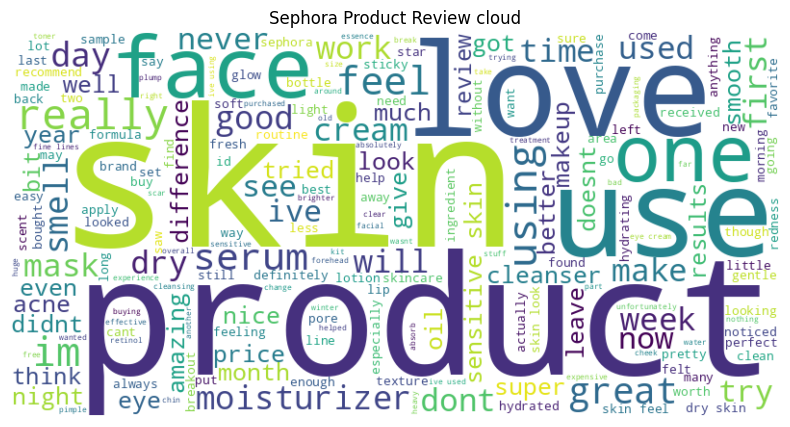

In [281]:
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Sephora Product Review cloud")
plt.show()

In [282]:
candidate_topics = ['Effectiveness', 'Skin compatibility', 'Texture and application', 'Irritation', 'Scent', 'Packaging', 'Value for money', 'Repurchase']

In [283]:
topic_classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [284]:
customer_reviews = df_smaller['review_text'].to_list()
customer_reviews

['I love this. The price point is awesome, considering you’d pay that or more for a one time treatment in the dermatologist’s office. It definitely works because it is essentially sanding your skin, if you are not noticing any difference, try a higher disc.  definitely start with the training disc to get the hang of it, but then move it up to the next until you are seeing it work! its worth the investment! also the refill discs are only $20 and each disc lasts 3/4 times (a month)',
 'Do not use if you have oily or combo skin. The 3rd ingredient, isopropyl myristate, is known to clog pores or cause acne inflammation. I rarely get pimples except for an old faithful one or two around my period each month. But after using this a few days I had one huge pimple on my forehead. Never experienced before but I decided it was coincidence as I’m trying to get better washing my face nightly. But then I had 2, then 4. All cyst like and painful. Sadly I’m tossing this jar ASAP. It’s hydrating but al

In [286]:
from tqdm.notebook import tqdm

topics = []
for review in tqdm(customer_reviews, desc="Classifying reviews"):
  result = topic_classifier(review, candidate_topics)
  topic = result['labels'][0]
  topics.append(topic)

Classifying reviews:   0%|          | 0/300 [00:00<?, ?it/s]

In [287]:
df_smaller['Topics'] = topics

In [289]:
df_smaller[['review_text', 'Topics']].head(10)

,review_text,Topics
33166,"I love this. The price point is awesome, consi...",Value for money
32228,Do not use if you have oily or combo skin. The...,Effectiveness
24280,"As amazing, easy and effective as this product...",Effectiveness
36852,This cleanser is so great! It removes perfectl...,Packaging
3489,I am so happy and blown away. I have a tooth t...,Value for money
12028,This product is fantastic. I use it as a serum...,Value for money
8353,Walk far far far away from this product. NEVER...,Texture and application
8279,For those who love sheet masks but don’t have ...,Effectiveness
21034,I love all of Paulas choice but especially thi...,Value for money
49098,I barely even dropped this and it shattered an...,Value for money
